# Week 3 - Part C: prove the palette

About 1 man in 12 and 1 woman in 200 has some colour-vision deficiency. In a class of 60 that is roughly three people who will not tell me my chart is unreadable. So instead of trusting a palette, I simulate it and measure it.

- Simulation: `vizlib.simulate_cvd()` - Machado, Oliveira & Fernandes (2009), severity 1.0, applied in linear RGB.
- Distance: `vizlib.worst_pair()` - every pair compared in OKLab (x100), where one threshold means the same thing for every hue. Thresholds: >= 15 clear, >= 8 ok, 6-8 needs a second channel, < 6 fails.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Works both as a notebook (opened from week3/) and as a script (week3/submission/x.py)
try:
    ROOT = Path(__file__).resolve().parents[1]
    IN_NOTEBOOK = False
except NameError:
    ROOT = Path.cwd()
    IN_NOTEBOOK = True
sys.path.insert(0, str(ROOT))

import vizlib
from vizlib import PALETTE, MARKERS, save_fig, style_defaults

DATA = ROOT / "data"
CHARTS = ROOT / "charts"
SUB = ROOT / "submission"
CHARTS.mkdir(exist_ok=True)
SUB.mkdir(exist_ok=True)

style_defaults()                      # house rcParams, set once
BLUE, ORANGE, GREEN = PALETTE["series"]
PINK = PALETTE["series_4th"]
GREY = PALETTE["muted"]
INK = PALETTE["ink"]
INK_SOFT = PALETTE["ink_soft"]
SRC = "Synthetic data generated for CDB601220 (Week 3)."
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
warnings.filterwarnings("ignore", category=FutureWarning)


def finish(fig, name, note, folder=None):
    """Save FIRST (300 dpi, source note), then show. Never the other way round."""
    path = save_fig(fig, (folder or CHARTS) / f"{name}.png", note)
    if IN_NOTEBOOK:
        plt.show()
    plt.close(fig)
    print("saved ->", Path(path).relative_to(ROOT))
    return path


In [2]:
from matplotlib.patches import Rectangle

MY_PALETTE = ["#1F77B4", "#FF7F0E", "#2CA02C", "#D62728"]      # matplotlib tab10, first four - the default everyone uses
MY_LABEL = "matplotlib tab10 (first four) - the default"
COURSE = PALETTE["series"] + [PALETTE["series_4th"]]
COURSE_LABEL = "Course palette (3 slots + 4th)"
KINDS = ["normal", "deutan", "protan", "tritan"]

for pal, lab in [(MY_PALETTE, MY_LABEL), (COURSE, COURSE_LABEL)]:
    print(lab)
    for k in KINDS[1:]:
        print(f"  {k}: {pal} -> {vizlib.simulate_cvd(pal, k)}")

matplotlib tab10 (first four) - the default
  deutan: ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'] -> ['#456CB3', '#C4AE05', '#968838', '#8B7C1F']
  protan: ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'] -> ['#5A79B7', '#A59100', '#A39119', '#615725']
  tritan: ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'] -> ['#00868D', '#FF616D', '#009B89', '#EC002B']
Course palette (3 slots + 4th)
  deutan: ['#0072B2', '#D55E00', '#009E73', '#CC79A7'] -> ['#3B67B1', '#9E8C00', '#8A8676', '#9498A5']
  protan: ['#0072B2', '#D55E00', '#009E73', '#CC79A7'] -> ['#5375B5', '#817100', '#9A9271', '#808BA9']
  tritan: ['#0072B2', '#D55E00', '#009E73', '#CC79A7'] -> ['#008289', '#EB4050', '#009E92', '#D6788A']


## Q1 and Q2 - before / after swatches (5 marks)

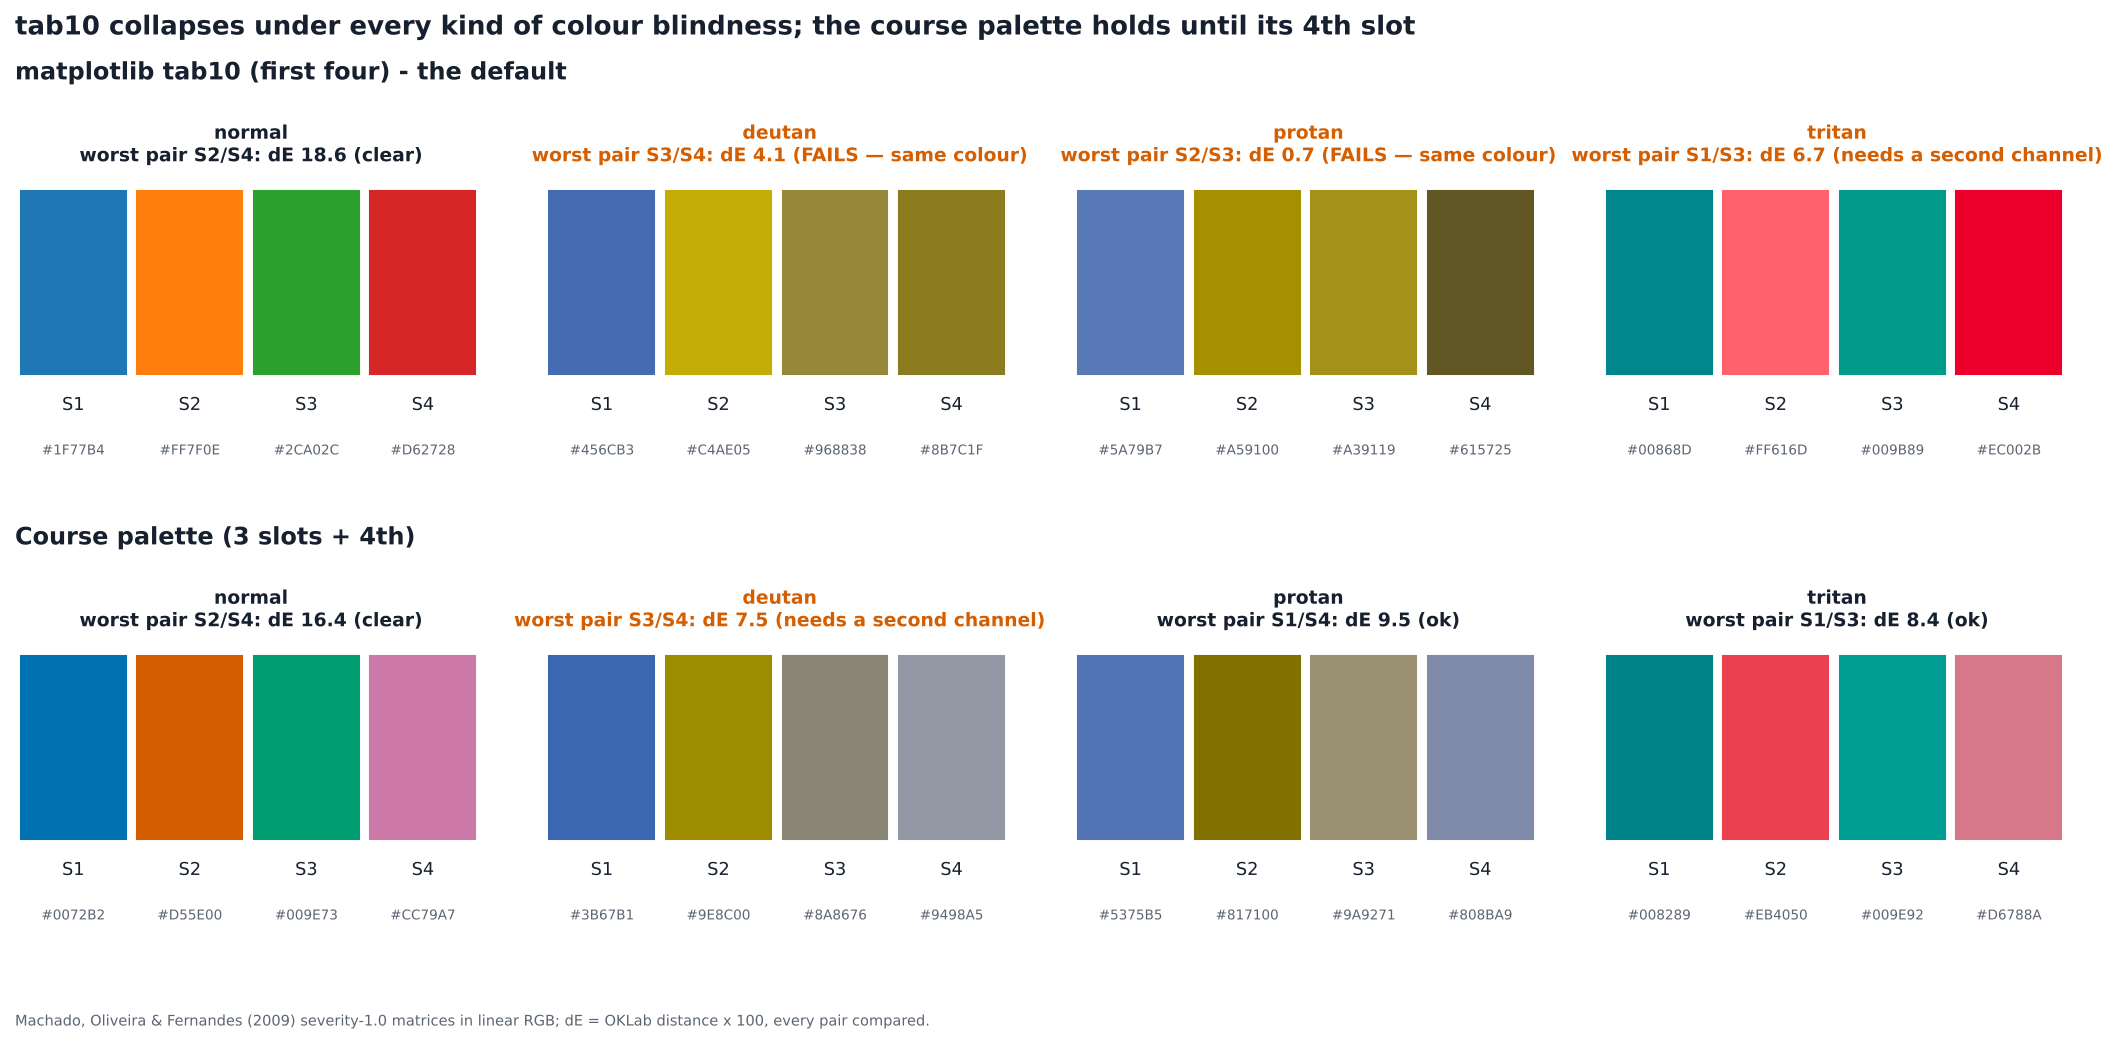

saved -> submission/partC_palette.png


'/home/claude/week3/submission/partC_palette.png'

In [3]:
def swatch_sheet(palettes):
    fig = plt.figure(figsize=(14, 3.1 * len(palettes)))
    subs = fig.subfigures(len(palettes), 1)
    for sf, (pal, label) in zip(subs, palettes):
        axes = sf.subplots(1, len(KINDS))
        sf.suptitle(label, x=0.01, ha="left", fontsize=11.5, fontweight="bold")
        for ax, kind in zip(axes, KINDS):
            shown = pal if kind == "normal" else vizlib.simulate_cvd(pal, kind)
            i_, j_, *_, d = vizlib.worst_pair(pal, kind)
            for i, h in enumerate(shown):
                ax.add_patch(Rectangle((i, 0), 0.9, 1, color=h))
                ax.text(i + 0.45, -0.12, f"S{i+1}", ha="center", va="top", fontsize=8.5, color=INK)
                ax.text(i + 0.45, -0.38, h, ha="center", va="top", fontsize=6.5, color=INK_SOFT)
            ax.set_xlim(-0.05, len(pal)); ax.set_ylim(-0.65, 1.05); ax.axis("off")
            ax.set_title(f"{kind}\nworst pair S{i_}/S{j_}: dE {d:.1f} ({vizlib.verdict(d)})", fontsize=9,
                         color=ORANGE if d < 8 else INK, loc="center")
        sf.subplots_adjust(left=0.01, right=0.99, top=0.72, bottom=0.05, wspace=0.12)
    fig.suptitle("tab10 collapses under every kind of colour blindness; the course palette holds until its 4th slot",
                 x=0.01, ha="left", y=1.04, fontsize=12.5, fontweight="bold")
    return fig


fig = swatch_sheet([(MY_PALETTE, MY_LABEL), (COURSE, COURSE_LABEL)])
finish(fig, "partC_palette", "Machado, Oliveira & Fernandes (2009) severity-1.0 matrices in linear RGB; dE = OKLab distance x 100, every pair compared.",
       folder=SUB)

**What this chart shows.** The default matplotlib colours fall apart under colour blindness. Red and green, or orange and green, become nearly the same colour. The course palette's first three colours stay distinct in every simulation, and only the 4th pink one gets too close to green, so it needs labels as well.

## Q3 - the worst pair in each palette (2 marks)

In [4]:
def audit(pal, label):
    rows = []
    for kind in KINDS:
        i, j, a, b, d = vizlib.worst_pair(pal, kind)
        rows.append({"palette": label, "vision": kind, "worst pair": f"S{i} {a} / S{j} {b}", "dE": round(d, 1),
                     "verdict": vizlib.verdict(d)})
    return rows


tab = pd.DataFrame(audit(MY_PALETTE, "tab10 first four") + audit(COURSE, "course 3 + 4th")
                   + audit(PALETTE["series"], "course 3 only"))
print(tab.to_string(index=False))
print()
d_rg = vizlib.delta_e(*vizlib.simulate_cvd(["#2CA02C", "#D62728"], "deutan"))
print(f"tab10 green vs red under deuteranopia: dE {d_rg:.1f}")

         palette vision              worst pair   dE                verdict
tab10 first four normal S2 #FF7F0E / S4 #D62728 18.6                  clear
tab10 first four deutan S3 #2CA02C / S4 #D62728  4.1    FAILS — same colour
tab10 first four protan S2 #FF7F0E / S3 #2CA02C  0.7    FAILS — same colour
tab10 first four tritan S1 #1F77B4 / S3 #2CA02C  6.7 needs a second channel
  course 3 + 4th normal S2 #D55E00 / S4 #CC79A7 16.4                  clear
  course 3 + 4th deutan S3 #009E73 / S4 #CC79A7  7.5 needs a second channel
  course 3 + 4th protan S1 #0072B2 / S4 #CC79A7  9.5                     ok
  course 3 + 4th tritan S1 #0072B2 / S3 #009E73  8.4                     ok
   course 3 only normal S1 #0072B2 / S3 #009E73 18.7                  clear
   course 3 only deutan S2 #D55E00 / S3 #009E73 11.0                     ok
   course 3 only protan S2 #D55E00 / S3 #009E73 13.0                     ok
   course 3 only tritan S1 #0072B2 / S3 #009E73  8.4                     ok

tab10 green

**tab10 fails under all three simulations.** Under deuteranopia (the common one) the pair that collapses is the one everyone uses for good vs bad - **S3 green `#2CA02C` and S4 red `#D62728`, dE 4.1: "the same colour"**. Under protanopia it is even worse: **S2 orange and S3 green fall to dE 0.7**, which means they are literally indistinguishable. Under tritanopia blue and green drop to 6.7. So a "pass / fail" or "on target / behind" chart in default matplotlib colours is unreadable for roughly 1 man in 12, and nothing on the screen would warn me.

**The course palette:** the three core slots never fall below 8 under any simulation (worst is S2/S3 under deuteranopia, dE 11.0, "ok"). But **adding the 4th slot `#CC79A7` creates a weak pair: S3 green / S4 pink drops to dE 7.5 under deuteranopia**, which is in the 6-8 band - "legal only with a second encoding channel". It is also below 3:1 contrast on white. What that means for me: **I am allowed to use the 4th colour only when the series also carries a direct label, a different marker shape, or a table view.** Colour can never be the only thing telling those two series apart.

## Q4 - my rule for more than three categories (2 marks)

**Three colours is the ceiling.** If a chart needs a fourth category or more, I do not reach for a bigger palette; I add something that is not colour:

1. **Direct labels** on the lines or bars instead of a legend, so identity is carried by text.
2. **Redundant marker shapes** (`o`, `s`, `^`, `D` from `vizlib.MARKERS`) so the series still separate in greyscale and under every CVD simulation.
3. **Grey for context, one colour for the message** - most of the time only one or two categories matter, and the rest can be `PALETTE["muted"]`.
4. **Small multiples** when every category matters equally - one panel per category, same axes, so position does the work instead of hue.

And I run `simulate_cvd` on the exported PNG, not just on the hex list, before I hand anything in.

## Extra - simulating my own Part D figure

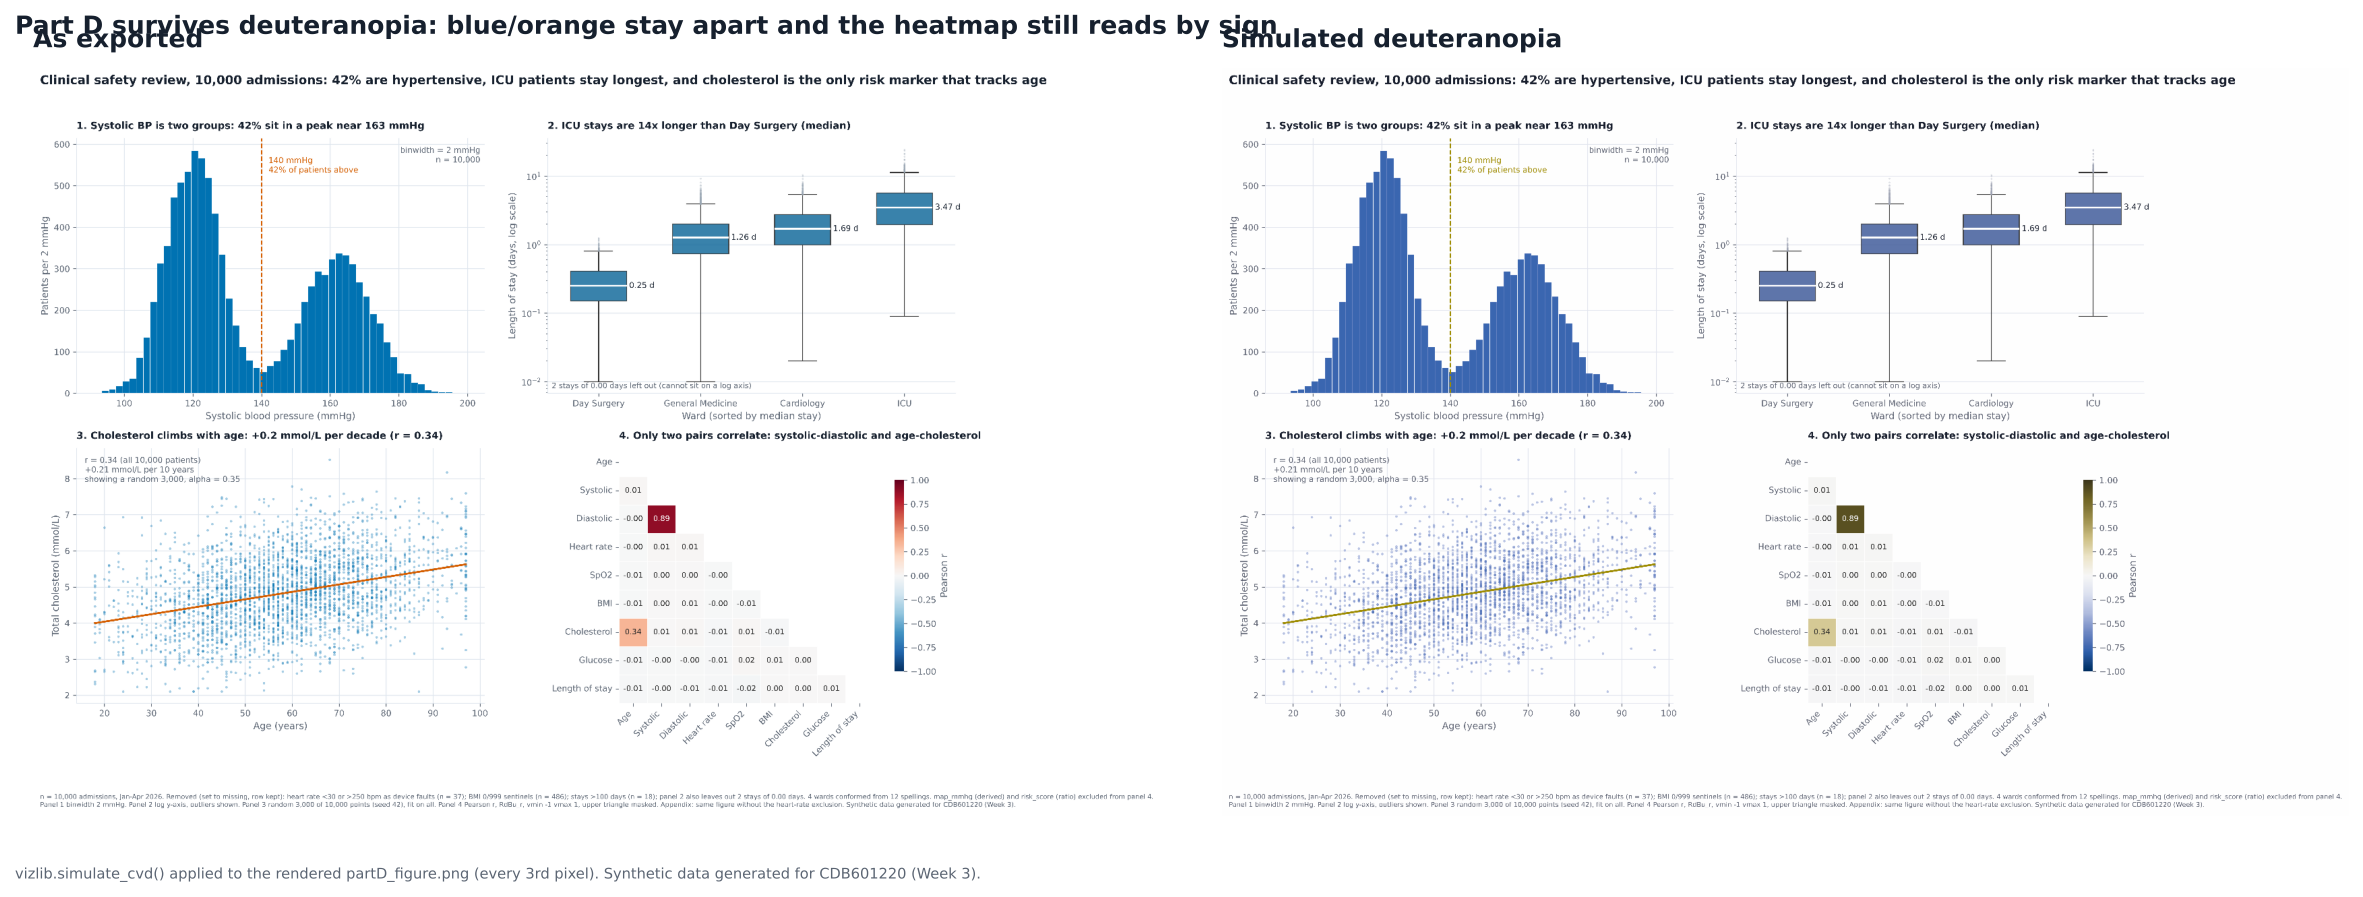

saved -> charts/partC_partD_deutan_check.png


In [5]:
import matplotlib.image as mpimg
src = SUB / "partD_figure.png"
if src.exists():
    img = mpimg.imread(src)[..., :3]
    step = 3                                          # downsample so the sheet stays a reasonable size
    img = img[::step, ::step]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5.6))
    for ax, (im, t) in zip(axes, [(img, "As exported"), (vizlib.simulate_cvd(img, "deutan"), "Simulated deuteranopia")]):
        ax.imshow(np.clip(im, 0, 1)); ax.axis("off"); ax.set_title(t)
    fig.suptitle("Part D survives deuteranopia: blue/orange stay apart and the heatmap still reads by sign",
                 x=0.01, ha="left", fontweight="bold")
    fig.tight_layout()
    finish(fig, "partC_partD_deutan_check", "vizlib.simulate_cvd() applied to the rendered partD_figure.png (every 3rd pixel). " + SRC)
else:
    print("Run partD_clinical_figure first to create submission/partD_figure.png")

**What this chart shows.** I ran my own Part D figure through the deuteranopia simulation to check it. The blue and orange are still easy to tell apart, and the heatmap still shows which correlations are positive and which are negative. So the figure works for colour-blind readers too.